In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

In [ ]:
df.shape

df.info()


In [ ]:
df.describe()

df.head()

df["YearsAtCompany"].unique()

In [ ]:
sns.boxplot(x="Attrition", y="YearsAtCompany", data=df)
plt.show()



pd.crosstab(df["BusinessTravel"], df["Attrition"], normalize="index")

In [ ]:
df["Attrition"].unique()

df["BusinessTravel"].unique()

df["Department"].unique()

df["StandardHours"].unique()

df["EmployeeCount"].unique()

df["StockOptionLevel"].unique()

df["TrainingTimesLastYear"].unique()

df["WorkLifeBalance"].unique()




In [ ]:
df["Attrition"].value_counts().plot(kind="bar")

# df["BusinessTravel"].value_counts()

# df["Department"].value_counts()

plt.show()

In [ ]:
sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df
)

plt.show()

pd.crosstab(df["OverTime"], df["Attrition"], normalize="index")

df.head()

In [ ]:

# Feature Classification 
print(df.columns)

identifier_features =  "EmployeeNumber"

target = "Attrition"

numerik_features = [
    "Age",
    "DistanceFromHome",
    "DailyRate",
    "HourlyRate",
    "MonthlyIncome",
    "MonthlyRate",
    "NumCompaniesWorked",
    "PercentSalaryHike",
    "TotalWorkingYears",
    "TrainingTimesLastYear",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

ordinal_features = [
    "JobLevel",
    "Education",
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "JobSatisfaction",
    "PerformanceRating",
    "RelationshipSatisfaction",
    "StockOptionLevel",
    "WorkLifeBalance"
]

nominal_features = [
    "BusinessTravel",
    "Department",
    "EducationField",
    "Gender",
    "JobRole",
    "MaritalStatus",
    "OverTime",
]

drop_columns = [
    "EmployeeCount",
    "Over18",
    "StandardHours"
]



In [ ]:
#EDA

df[numerik_features].hist(figsize=(18,12))
plt.tight_layout()
plt.show()

In [ ]:
corr = df[numerik_features].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [ ]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"] #series, jika kita tambah lagi [], maka akan menjadi dataframe, untuk preprocessing y nanti, kita menggunakan series untuk mappingnya

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

df["Education"].head()


        


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

#Membuat satu object scaler yang nanti menyimpan hasil pembelajaran data training, lalu menggunakan scaler yang sama untuk training dan testing
scaler = StandardScaler()

#Menyimpan data (mean, standarddeviasion untuk setiap fitur numerik)
# Tidak menggunakan fit pada X_test karena kita tidak ingin data tes belajar langsung
scaler.fit(X_train[numerik_features])

scaler.mean_
scaler.scale_

#Menggunakan data dari scaler numerik tadi untuk mengubah numerik features 
X_train_scaled = scaler.transform(X_train[numerik_features])
X_test_scaled = scaler.transform(X_test[numerik_features])

#Mengubah menjadi dataframe, karena default scikitlearn scaler adalah numpy.ndarray, bukan pandas df
X_train_scaled = pd.DataFrame(X_train_scaled, columns=numerik_features, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=numerik_features, index=X_test.index)

# X_train_scaled.head()
# X_test_scaled.head()

X_test_scaled.mean()

#pandas.std menggunakn sample std (ddof=1), sedangkan StandardScaler menggunakan ddof=0 (maka dari itu nilainya sedikit di atas 1)



In [ ]:
print("Mean scaler: ")
print(scaler.mean_)

print("\n Mean X_train_scaled: ")
print(X_train_scaled.mean())

print("\n Std X_train_scaled: ")
print(X_train_scaled.std())

X_train_scaled.head()

In [ ]:
# handleunknown berguna untuk jika mempunyai kategori baru yang belum pernah ditraining, maka akan dihandle sebagai kategori tidak memiliki kolom aktif
# OneHotEncoder memiliki bawaan sparsematrix, yaitu format hemat memori duntuk data dengan banyak nilai 0
# Karena data kita kecil, lebih nyaman jika kita tidak gunakan dan pakai array biasa agar bisa dijadikan datafram

# gunakan onehotencoder agar tidak bias urutan, business travel no tidak lebih besar daripada yang frequently, jadi gunakan bilangan 0 1 saja
# Jika anda memiliki business travel frequently, dia akan memiliki nilai 0, dan sisanya seperti nontravel akan memiliki 1
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoder.fit(X_train[nominal_features])

# Encoder memecah masing masing menjadi kolom biner
# Apakah karyawan ini bagian ddari department sales, hasilnya bakal ngeluarin 1 0 
encoder.get_feature_names_out(nominal_features)

encoder.categories_

In [ ]:
X_train_encoded = encoder.transform(X_train[nominal_features])
X_test_encoded = encoder.transform(X_test[nominal_features])

X_train_encoded = pd.DataFrame(X_train_encoded, 
                               columns=encoder.get_feature_names_out(nominal_features),
                               index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded, 
                              columns=encoder.get_feature_names_out(nominal_features),
                              index=X_test.index)

# Index acak karena imbas langsung dari train test split yang acak, karena itu saat kita ubah ke pd datafram leagi, kita masih mempertahankan X_train/test index

X_train_encoded.head()




In [ ]:
# kita gabungkan (nilai ordinal kita ikutkan scaling dasar untuk mwnstadardisasi niklainya agar tidak terlalu jauh)
scaling_features = numerik_features + ordinal_features

# kita fitulang scaling feature, karena scaler kita hanya tahu 14 fitur numerik
scaler.fit(X_train[scaling_features])

X_train_scaled = scaler.transform(X_train[scaling_features])
X_test_scaled = scaler.transform(X_test[scaling_features])

X_train_scaled = pd.DataFrame(X_train_scaled,
                                columns=scaling_features,
                                index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled,
                             columns=scaling_features,
                             index=X_test.index)

In [ ]:
# kita gabungkan seluruh fitur yang ada menggunakan pd.concat

# Menggunakan axis 1 karena kita menambah kolom bukan baris, axis=1, artinya operasi dilakukan sepanjang kolom 
# Kalau axis 0 kita menambah baris
X_train_final = pd.concat([X_train_scaled, X_train_encoded], axis=1)
X_test_final = pd.concat([X_test_scaled, X_test_encoded], axis=1)

X_train_final.columns.tolist()
X_test_final.isnull().sum().sum()



In [ ]:
# Kita ubah target menjadi fitur numerik, karena logistic regression membutuhkan numerik
# Untuk target y, tidak menggunakan OneHotEncoder karena kita membutuhkan hanya satu kolom Yes or no, bukan keduanya

# !!!Kita define sekali lagi, karena mengamankan depedency nya, mungkin diatas ada yang tertimpa data y_train dan test (HARUS DIHAPUS SAAT MERAPIKAN KODE!!)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2,
                                                    random_state=42)
# y_train = y_train.map({"No": 0, "Yes": 1})
# y_test = y_test.map({"No": 0, "Yes": 1})

y_train = y_train.map({"No": 0, "Yes": 1})
y_test = y_test.map({"No": 0, "Yes": 1})

print(y_train.unique())
print(y_train.value_counts())

print(y_test.unique())
print(y_test.value_counts())


print("\n", X_train_final.shape)
print(X_test_final.shape)
print(y_train.shape)
print(y_test.shape)


# Restart Kernel sebelum deploy ke app



In [ ]:
from sklearn.linear_model import LogisticRegression
# Training Logistic Regression

# logreg menggunakan iterasi untuk mencari parameter terbaik, kita gunakan max yang longgar agar mencapai konvergensi
model = LogisticRegression(max_iter=1000, random_state=42)


# LogReg pada dasarnya menggunakan persamaan linear z = b0 + b1x1 + b2x2 + ..... + b51x51, dengan b1..b51 = coef dan x1..x51 = nilai fitur
# Setelah Z dihitung, LOGREG menggunakan fungsi Sigmoid untuk mengubahnya menjadi probabilitas. dan saat itulah threshold dengan contoh nilai 0.82 akan dibandingkan dengan nilai 5 untuk menentukan attrition

# Jangan masukkan data training
model.fit(X_train_final, y_train)

# Akan mengeluarkan (1,51), 1 target dan 51 koefisien 
# Koefisien menunjukan menunjukan arah dan kekuatan pengaruh ke log-odds attrition, tetapi bukan langsung probabilitas
# Koef > 0 (kecenderungan menuju attrition=1, meningkat)
# Koef < 0 (kecenderungan menuju attrition=1 menurun)
print(model.coef_.shape)
#nilai dasar model sebelum kontribusi seluruh fitur dimasukkan, masih pada skala log-odds bukan probabilitas
print(model.intercept_)

coef_df = pd.DataFrame({"feature": X_train_final.columns,
                        "coefficient": model.coef_[0]})

coef_df.sort_values("coefficient", ascending=False)

# Hati hati, Logreg menunjukan bahwa dengan fitur lain dalam model tetap, faktor tersebut berkaitan dengan kecenderungan prediksi ke attrition=1, karena itu faktor lain harus dipertimbangkan



In [26]:
# mengubah menjadi nilai absolut agar melihat mana saja fitur yang memiliki magnitud terkuat ke attrition
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df.sort_values("abs_coefficient", ascending=False).head(10)

#model yang sudah kita latih, kita kasih X_test_final untuk menghasilkan prediksi
y_pred = model.predict(X_test_final)

Accuracy:  0.8945578231292517
Precision:  0.6428571428571429
Recall:  0.46153846153846156
F1 Score:  0.5373134328358209


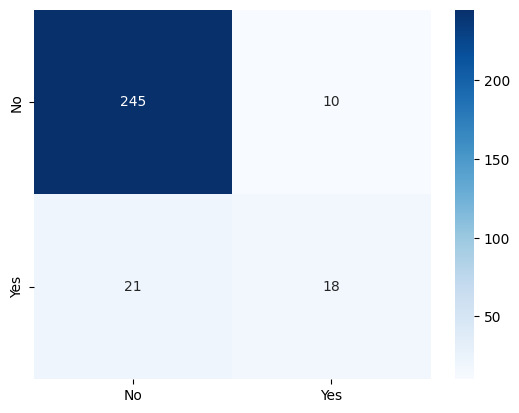

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Jangan langsung accuracy karena kita masih memiliki imbalanced dataset dengan attrition no lebih banyak
cm = confusion_matrix(y_test, y_pred)

#TN (True Negative) memang tidak resign, model bilang tidak
#TP (True Postive) memang resign, model bilang resign
#FP (False Positive) tidak resign, model bilang resign
#FN (False Negative) resign, tapi model gagal memprediksinya

sns.heatmap(
    cm,
    annot=True, #Tampilkan angka dalam kotak
    fmt="d", #Tampilkan sebagai bilangan bulat, bukan desimal
    cmap="Blues",
    xticklabels=["No", "Yes"], #Memberi label kelas agar tidak hanya melihat angka
    yticklabels=["No", "Yes"]
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy: ", accuracy) #Berapa prediksi yang benar
print("Precision: ", precision) #Dari semua yang resign, berapa yang benar benar resign misal 0.60  , dari 100 orang yang model prediksi resign, 60 yang resign 
print("Recall: ", recall) #Dari semua orang yang resign, berapa yang berhasil ditemukan model, misal 0.70, dari 100 orang yang resign, model berhasil menemukan 70
print("F1 Score: ", f1) #F1 berusaha menyeimbangkan precision dan recall ketika ingin mempertimbangkn keduanya, terutama pada imbalanced datasets   

# Accuracy, 